<h1 style='text-align: center'>Visualizing Neural Networks using t-SNE and UMAP</h1>
</br>
A general issue in machine learning is that we often have to trade off model interpretability for prediction accuracy. This is especially true for neural networks, where we have a very complex shape of the function $f$, that connects the input variables to the output variables. 

In this notebook, I want to demonstrate two techniques that can used to visualize neural networks.
I will demonstrate the techniques on the well-known MNIST dataset. 

**Outline**

1. Dataset Overview
2. MNIST Classifier
3. t-SNE Visualization
4. UMAP Visualization
5. Performance Comparison

In [2]:
!pip install pytorch_lightning 
import numpy as np
import torch
import torch.nn as nn
import torchvision
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import pytorch_lightning as pl
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
import cuml
import sklearn
import umap
import timeit

torch.manual_seed(42)
np.random.seed(42)

# 1. Dataset Overview

Let's first have a quick overview of the data we are dealing with. The MNIST dataset contains handwritten digits 0 to 9.

In [3]:
# Install kagglehub if it's not already in your Colab environment
!pip install kagglehub -q

import kagglehub
import pandas as pd
import os

# 1. Authenticate securely (this will prompt you to log in, no hardcoded keys needed!)
kagglehub.login()

# 2. Download the competition dataset 
# Notice we use competition_download() instead of dataset_download()
print("Downloading competition data from Kaggle...")
dataset_path = kagglehub.competition_download("digit-recognizer")
print(f"Dataset downloaded to: {dataset_path}")

# 3. Load the data directly into pandas
train = pd.read_csv(os.path.join(dataset_path, "train.csv"))
test = pd.read_csv(os.path.join(dataset_path, "test.csv"))

print("Data loaded successfully!")
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Dataset downloaded to: /root/.cache/kagglehub/competitions/digit-recognizer
Data loaded successfully!
Train shape: (42000, 785)
Test shape: (28000, 784)


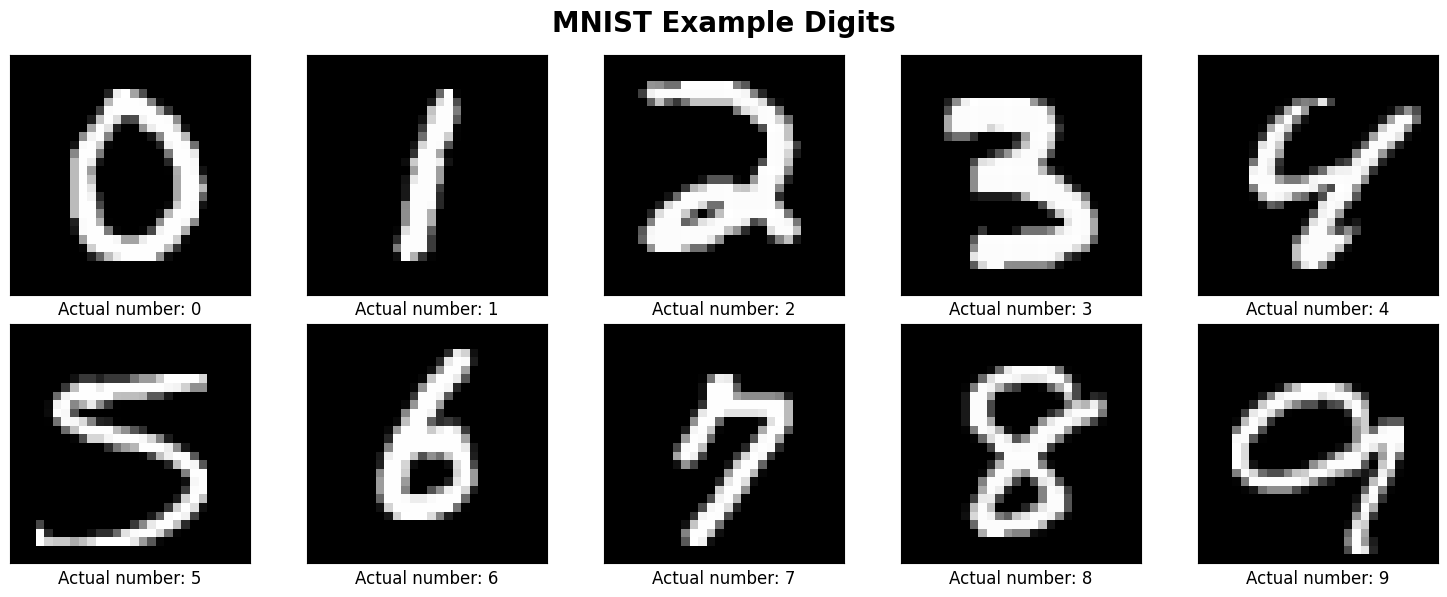

In [4]:


fig, ax = plt.subplots(2, 5, figsize=(15,6))
for a in ax.ravel():
    a.set(xticks=[], yticks=[])
r = 0
for c, num in zip(itertools.cycle([0,1,2,3,4]), range(10)):
    img = train.loc[train.label == num].sample()
    img = img.iloc[:, 1:].to_numpy()
    img = np.resize(img, (28,28))
    ax[r, c].imshow(img, cmap='gray')
    ax[r, c].set_xlabel(f'Actual number: {num}', fontsize=12)
    if c == 4:
        r += 1
fig.suptitle('MNIST Example Digits', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. MNIST Classifier

In this section, I will construct and train a simple CNN to predict the digit of a given image. The MNIST Classifier will consist of 2 convolutional layers and 2 fully connected layers. Since this is not an important part, I will not describe my procedure in greater detail, since this is not the reason for this notebook. You can take a look at the code to get a better understanding of the architecture.

In [5]:
class MNISTDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.data = pd.read_csv(csv_path)
        self.transform = transform
        
    def __len__(self):
        return self.data.shape[0]
    
    def __getitem__(self, idx):
        img = self.data.iloc[idx, 1:].to_numpy().reshape(28, 28).astype(np.float32)
        label = self.data.iloc[idx, 0]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

In [6]:
class MNISTClassifier(pl.LightningModule):
    def __init__(self, hparams):
        super(MNISTClassifier, self).__init__()
        self.save_hyperparameters(hparams)
        self.input_size = 28*28
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5), 
            nn.AvgPool2d(2), 
            nn.ReLU(),   
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5), 
            nn.MaxPool2d(2), 
            nn.ReLU(), 
            nn.Flatten()
            )
        self.fc1 = nn.Linear(256, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        out = self.conv(x)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out
        
    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.forward(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        self.log('train_loss', loss, prog_bar=True)
        return loss
        
    def validation_step(self, batch, batch_idx):
        images, labels = batch

        outputs = self.forward(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        self.log('val_loss', loss, prog_bar=True)
        
#     def test_step(self, batch, batch_idx):
#         images, labels = batch
#         images = images.reshape(-1,1,28, 28).float() 
        
#         prediction = self.forward(images)
#         accuracy = torch.sum(prediction == labels).item() / (len(prediction) * 1.0)
#         return accuracy
    
#     def test_epoch_end(self, step_accuracy):
#         acc = 0
#         for i in step_accuracy:
#             acc += i.mean() / len(self.dataset['test'])
#         print(f'Test accuracy: {acc:.3f}')
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams['lr'])
    
    def prepare_data(self):
        train_path = os.path.join(dataset_path, "train.csv")
        test_path = os.path.join(dataset_path, "test.csv")
        
        mean = train.iloc[:, 1:].values.mean() / 255.0
        std = train.iloc[:, 1:].values.std() / 255.0
        
        transform = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize((mean,), (std,))
        ])
        
        dataset = MNISTDataset(train_path, transform=transform)
        train_data, val_data = torch.utils.data.random_split(dataset, [33600, 8400])
        test_data = MNISTDataset(test_path, transform=transform)
        
        self.dataset = {
            'train': train_data,
            'val': val_data,
            'test': test_data
        }
        
    def train_dataloader(self):
        return DataLoader(self.dataset['train'], shuffle=True, batch_size=self.hparams['batch_size'], num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.dataset['val'], shuffle=False, batch_size=self.hparams['batch_size'], num_workers=4)
        
    def test_dataloader(self):
        return DataLoader(self.dataset['test'], shuffle=False, batch_size=self.hparams['batch_size'], num_workers=4)

In [ ]:
hparams = {"lr": 1e-3,
           "batch_size": 32}

model = MNISTClassifier(hparams)

trainer = Trainer(
    max_epochs=10,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3)],
    accelerator='auto',
    devices='auto'
)
trainer.fit(model)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv │ Sequential │  2.6 K │ train │     0 │
│ 1 │ fc1  │ Linear     │ 30.8 K │ train │     0 │
│ 2 │ fc2  │ Linear     │ 10.2 K │ train │     0 │
│ 3 │ fc3  │ Linear     │    850 │ train │     0 │
│ 4 │ relu │ ReLU       │      0 │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 44.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 44.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 12                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will 
create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will 
create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

# 3. t-SNE Visualization

Now that we have our model fully trained, we can start with the t-SNE visualization. t-SNE stands for t-distributed stochastic neighborhood embedding
and tries to map high-dimensional data into lower dimensions while preserving both the local and global neighborhood structure. Details of the exact algorithm can be found in the paper [1].

The algorithm has many parameters that can be tuned, but the most important one is called $\textit{perplexity}$. It is used to balance the attention between local or global structure. It can be seen as a guess of how many close neighbors one point has in the high dimensional space.
A very good study of t-SNE, the hyperparameters and pitfalls can be found on [distill.pub](https://distill.pub/2016/misread-tsne/).

But now to the useful part. t-SNE gives us a tool to visualize high dimensional data. This high-dimensional data can for example be found after the CNN layers in our neural network. Both fully connected layers are very high in dimension (120-and 84-dimensional respectively). So when visualizing this layer, we can see how well the network has already been able to separate the digits in our dataset. To obtain the embeddings, we need to propagate the images through the network, but not until the final layer, but before, at the fully connected layer of interest. The following function does exactly that, capture the output after the second fully connected layer.

In [7]:
def embedding_fc2(data):
    model.eval()
    img = torch.Tensor(data.reshape(-1,1,28, 28)).float() #transform the image
    out = model.conv(img) #pass through CNN
    out = model.relu(model.fc1(out)) #pass through FC 1
    out = model.relu(model.fc2(out)) #pass through FC 2
    return out

The obtained embedding has to be fit and transformed using the t-SNE algorithm. [Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) has a function that performs the algorithm on the CPU. However, it takes very long to converge as the number of data points becomes larger. 
That is why we are going to use an alternative that runs on the GPU - RAPIDS [cuML](https://docs.rapids.ai/api/cuml/stable/api.html?highlight=tsne#cuml.TSNE) library. I am going to compare the performance in section 6.

We are going to use the cuML library in the following. The three hyperparameters that I have set are: 
- n_components: dimensionality of reduction
- perplexity: focus of attention on local or global structure (typically between 5 and 50)
- n_neighbors: the amout of nearest neighbors considered when doing the reduction (3\*perplexity is recommended in the documentation)

To get a better sense of the perplexity parameter, I am going the visualize the embeddings for 3 different perplexity levels: 5, 30 and 50.

NameError: name 'model' is not defined

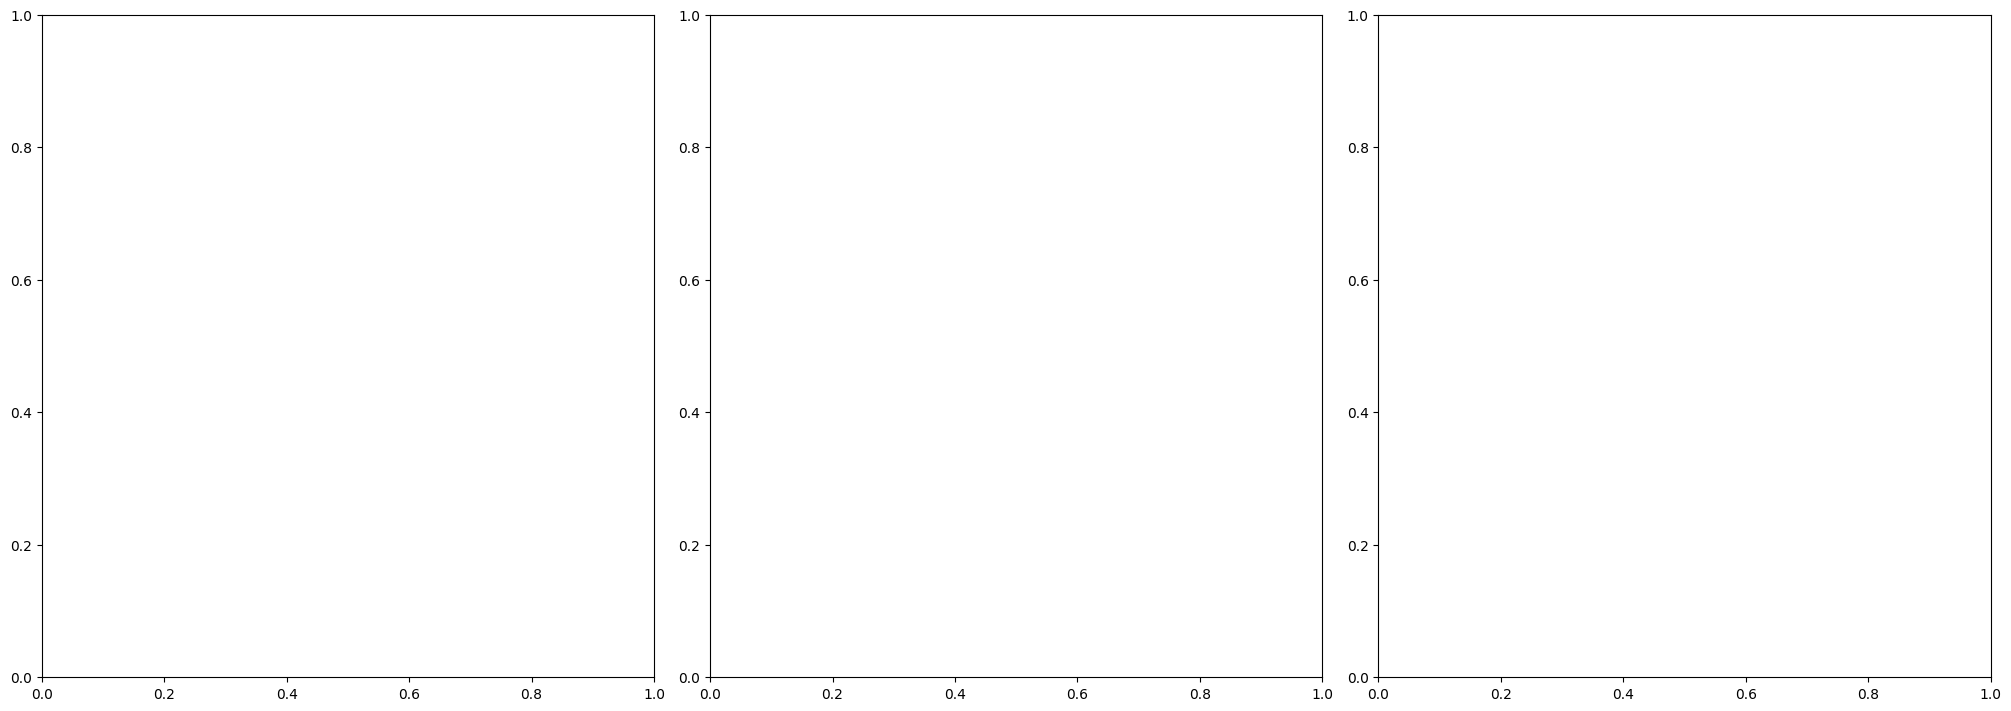

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20,7), constrained_layout=True)

img = train.iloc[:, 1:].to_numpy() #all images
label = train.iloc[:, 0] #all labels

embedding = embedding_fc2(img)

for c, per in zip(itertools.count(), [5, 30, 50]):
    tsne = cuml.manifold.TSNE(n_components=2,
                perplexity=per,
                n_neighbors=per*3)
    tsne = tsne.fit_transform(embedding.detach().numpy())
    scatter = ax[c].scatter(tsne[:, 0], tsne[:, 1], c=label, cmap='tab10', s=0.3)
    ax[c].set_title(f'Perplexity: {per}', fontsize=16)    

fig.suptitle('t-SNE Dimensionality reduction', fontweight='bold', fontsize=25)
cbar = fig.colorbar(scatter, boundaries=np.arange(11)-0.5, location='right')
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(np.arange(10))
plt.show()

We can see that across all the three different perplexity levels, the data is well structured and separated. That indicates that our network can successfully separate between the different digits. I want to mention that those three t-SNE results represent the same underlying data, so even though the right-most scatterplot seems to be better, in reality that has just to do with the way the dimensionality reduction has been constructed.

# 4. UMAP Visualization

An alternative to t-SNE is the UMAP dimensionality reduction algorithm. Uniform Manifold Approximation and Projection aims to preserve the manifold of the high dimensional data when mapping into the lower-dimensional representation. For details, please take a look at the paper ([2]). While t-SNE is still to most popular algorithm, UMAP turns out to be a very good alternative. What suprised me about it is that it can run quickly even on CPU, whereas t-SNE may take up to an several minutes. I am going to compare performance in the next section.

Now to the most important parameters of UMAP:
- n_components: dimensionality of reduction
- n_neighbors: tradeoff between local and global structure (lower values only take into consideration the local structure)
- min_dist: the minimum allowed distance in the lower structure; can prevent or encourage forming of clusters
- metric: what distance measure to use

As we can see, both algorithms share some hyperparameters, which is no suprise as they both are based on neighborhood structure.
You might want to also take a look at the [docs](https://umap-learn.readthedocs.io/en/latest/), they offer some great tutorials.

In [ ]:
umap_hparams = {'n_neighbors':5,
                'min_dist':0.1,
                'n_components':2,
                'metric':'euclidean'}

img = train.iloc[:, 1:].to_numpy() #all images
label = train.iloc[:, 0] #all labels
embedding = embedding_fc2(img)

fig, ax = plt.subplots(figsize=(11,8), constrained_layout=False)
ax.set(xticks=[], yticks=[])

umap_embedding = umap.UMAP(n_neighbors=umap_hparams['n_neighbors'], min_dist=umap_hparams['min_dist'], n_components=umap_hparams['n_components'], metric=umap_hparams['metric']).fit_transform(embedding.detach().numpy())
scatter = ax.scatter(x = umap_embedding[:,0], y = umap_embedding[:,1], s=0.3, c=label, cmap='tab10')

cbar = plt.colorbar(scatter, boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(np.arange(10))

plt.title('UMAP Dimensionality reduction', fontsize=25, fontweight='bold')
plt.show()

# 5. Performance Comparison

Now I am going to compare the three libraries Sklearn, cuML and umap based on performance. Obviously it is hard to compare t-SNE to UMAP as they are build on different mathematical foundation, but I still find is interesting to find out which algorithms performs better (especially since both are a great tool for visualizing high-dimensional data). I am going to time the algorithms on a randomly created 64-dimensional dataset. The time is tracked across different dataset sizes, ranging from 100 to 51200. I am going to use default settings for all algorithms/versions.

In [ ]:
sizes = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600, 51200]
dimension = 64

tsne_cpu_ = []
tsne_gpu_ = []
umap_ = []

for size in sizes:
    data = np.random.rand(size, dimension)

    a = timeit.default_timer()
    sklearn.manifold.TSNE().fit_transform(data)
    b = timeit.default_timer()
    tsne_cpu_.append(b-a)

for size in sizes:
    data = np.random.rand(size, dimension)
    
    a = timeit.default_timer()
    cuml.manifold.TSNE().fit_transform(data)
    b = timeit.default_timer()
    tsne_gpu_.append(b-a)
    
for size in sizes:
    data = np.random.rand(size, dimension)
    
    a = timeit.default_timer()
    umap.UMAP().fit_transform(data)
    b = timeit.default_timer()
    umap_.append(b-a)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
loc = np.arange(len(sizes))
width = 0.2

fig, ax = plt.subplots(figsize=(12,8))

r1 = ax.bar(loc-width, tsne_gpu_, width)
r2 = ax.bar(loc, umap_, width)
r3 = ax.bar(loc+width, tsne_cpu_, width)
ax.legend((r1[0], r2[0], r3[0]), ('t-SNE on GPU (cuML)', 'UMAP', 't-SNE on CPU (Sklearn)'), loc='upper left', fontsize=12)

ax.set(xticks=loc, xticklabels=sizes)
ax.yaxis.set_major_formatter('{x:.0f}s')
ax.set_ylabel('Time in Seconds', fontsize=12)
ax.set_xlabel('Data Size', fontsize=12)

plt.title(f'Performance Comparison on {dimension}-dimensional data', fontweight='bold', fontsize=20)
plt.show()

It is not surprising that the t-SNE algorithm running on GPU outperforms both CPU variations. However we can clearly see that UMAP scales better to large data in terms of time than Sklearn's t-SNE. Finally Sklearn's t-SNE has some weird variation in the graph which I cannot explain. I have timed it several times and there always seemed to be a peek in between the two extremes.

Overall, both algorithms offer some great insight into the complex data we are dealing with, and how well the model has been able to learn to segment different images.

# 7. Resources

[1] L. van der Maaten, G. Hinton; Visualizing Data using t-SNE; https://www.cs.toronto.edu/~hinton/absps/tsne.pdf

[2] L. McInnes, J. Healy, and J. Melville; UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction; http://arxiv.org/abs/1802.03426

<h2 style='text-align: center'>That you for reading this notebook to the end!<br>Feel free to upvote and leave a comment.</h2><h4 style='text-align: center'>Also please let me know what can be improved...<h4>